**Objective:** Perform a complete EDA on a synthetic patient health-risk dataset to understand
the data, clean it, and uncover patterns related to **heart disease risk**.

**Dataset:** `healthcare_dataset.csv` (2,025 patient records, 17 columns)

### 1.2 Column Dictionary

| Column | Description |
|---|---|
| patient_id | Unique patient identifier |
| age | Age in years |
| gender | Male / Female (raw data has inconsistent labels) |
| region | Geographic region |
| bmi | Body Mass Index |
| systolic_bp / diastolic_bp | Blood pressure readings (mmHg) |
| cholesterol | Total cholesterol (mg/dL) |
| glucose | Fasting glucose (mg/dL) |
| heart_rate | Resting heart rate (bpm) |
| smoking_status | Never / Former / Current |
| alcohol_consumption | None / Occasional / Regular |
| exercise_level | Low / Moderate / High |
| family_history | Family history of heart disease (Yes/No) |
| annual_income | Annual income (may contain invalid negatives) |
| hospital_visits_last_year | Count of hospital visits |
| heart_disease | **Target** — Yes/No |




## Project Roadmap
1. [Data Understanding](#1)
2. [Statistical analysis](#2)
3. [Data Cleaning](#3)
4. [Univariate Analysis](#4)
5. [Bivariate Analysis](#5)
6. [Multivariate Analysis](#6)
7. [Outlier Analysis (Deep Dive)](#7)
8. [Key Insights & Conclusion](#8)
---

1. [Data Understanding](#1)

In [39]:
# importting liabrares which was essential

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [40]:
df=pd.read_csv(r"healthcare_dataset.csv")

df.head()

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,P101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,NaN,Moderate,No,37000.0,1,No
1,P100140,88.0,Male,East,28.4,155.0,94.0,262.0,128.0,67.0,Never,NaN,Moderate,No,21000.0,8,Yes
2,P100110,37.0,Male,West,28.4,134.0,91.0,204.0,118.0,83.0,Former,NaN,Moderate,No,46000.0,2,Yes
3,P100638,75.0,Male,North,18.1,152.0,79.0,214.0,108.0,52.0,Current,NaN,Low,No,25300.0,5,Yes
4,P100702,30.0,Male,North,27.3,149.0,99.0,199.0,115.0,80.0,Former,Occasional,Low,Yes,65200.0,3,Yes


In [41]:
df.tail()

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
2020,P101603,40.0,Female,North,23.8,145.000000,81.0,242.0,98.0,73.0,Current,Occasional,High,Yes,43400.0,1,Yes
2021,P100502,87.0,Male,West,30.7,160.000000,96.0,246.0,121.0,76.0,Never,NaN,Low,No,NaN,2,Yes
2022,P100537,26.0,Female,West,21.7,125.000000,95.0,176.0,95.0,74.0,Never,NaN,Moderate,Yes,24200.0,3,Yes
2023,P101220,64.0,Male,North,31.2,150.000000,97.0,237.0,118.0,68.0,Former,Occasional,Moderate,No,53600.0,2,Yes
2024,P100175,51.0,Female,North,16.8,230.766341,83.0,223.0,99.0,76.0,Former,NaN,Moderate,No,42100.0,1,No


In [42]:
df.shape

(2025, 17)

In [43]:
df.head(1)

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,P101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,NaN,Moderate,No,37000.0,1,No


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 2025 non-null   str    
 1   age                        2025 non-null   float64
 2   gender                     2025 non-null   str    
 3   region                     2025 non-null   str    
 4   bmi                        1943 non-null   float64
 5   systolic_bp                2025 non-null   float64
 6   diastolic_bp               1965 non-null   float64
 7   cholesterol                1904 non-null   float64
 8   glucose                    1923 non-null   float64
 9   heart_rate                 2025 non-null   float64
 10  smoking_status             2025 non-null   str    
 11  alcohol_consumption        1211 non-null   str    
 12  exercise_level             1965 non-null   str    
 13  family_history             2025 non-null   str    
 14  ann

2. [Statistical analysis](#2)

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,2025.0,53.779423,21.048602,18.0,35.0,54.0,72.00,108.017232
bmi,1943.0,26.307874,4.760546,14.0,23.0,26.1,29.35,44.200000
systolic_bp,2025.0,144.104620,14.112953,103.0,135.0,144.0,152.00,258.041051
diastolic_bp,1965.0,86.173028,7.255701,62.0,81.0,86.0,91.00,110.000000
cholesterol,1904.0,216.598407,33.587026,148.0,198.0,214.0,232.00,487.924410
glucose,1923.0,118.570463,14.405478,62.0,109.0,118.0,128.00,168.000000
heart_rate,2025.0,71.190617,8.990235,41.0,65.0,71.0,77.00,99.000000
annual_income,1862.0,41985.392052,22887.161266,-57600.0,26600.0,37300.0,51000.00,191700.000000
hospital_visits_last_year,2025.0,3.318025,1.877839,0.0,2.0,3.0,5.00,11.000000


- Data insights:

 Annual_income may be outlier

In [46]:
df.describe(include="object").T

,count,unique,top,freq
patient_id,2025,2000,P101926,2
gender,2025,8,Female,1008
region,2025,4,North,594
smoking_status,2025,3,Never,1120
alcohol_consumption,1211,2,Occasional,865
exercise_level,1965,3,Moderate,906
family_history,2025,2,No,1371
heart_disease,2025,2,Yes,1495


# - Data cleaning

In [47]:
df.dtypes

patient_id                       str
age                          float64
gender                           str
region                           str
bmi                          float64
systolic_bp                  float64
diastolic_bp                 float64
cholesterol                  float64
glucose                      float64
heart_rate                   float64
smoking_status                   str
alcohol_consumption              str
exercise_level                   str
family_history                   str
annual_income                float64
hospital_visits_last_year      int64
heart_disease                    str
dtype: object

In [48]:
df.head()

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,P101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,NaN,Moderate,No,37000.0,1,No
1,P100140,88.0,Male,East,28.4,155.0,94.0,262.0,128.0,67.0,Never,NaN,Moderate,No,21000.0,8,Yes
2,P100110,37.0,Male,West,28.4,134.0,91.0,204.0,118.0,83.0,Former,NaN,Moderate,No,46000.0,2,Yes
3,P100638,75.0,Male,North,18.1,152.0,79.0,214.0,108.0,52.0,Current,NaN,Low,No,25300.0,5,Yes
4,P100702,30.0,Male,North,27.3,149.0,99.0,199.0,115.0,80.0,Former,Occasional,Low,Yes,65200.0,3,Yes


In [49]:
df["patient_id"]=df["patient_id"].str.replace("P",'')

In [50]:
df.head(1)

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,NaN,Moderate,No,37000.0,1,No


In [51]:
df.dtypes

patient_id                       str
age                          float64
gender                           str
region                           str
bmi                          float64
systolic_bp                  float64
diastolic_bp                 float64
cholesterol                  float64
glucose                      float64
heart_rate                   float64
smoking_status                   str
alcohol_consumption              str
exercise_level                   str
family_history                   str
annual_income                float64
hospital_visits_last_year      int64
heart_disease                    str
dtype: object

In [52]:
df["patient_id"]=df["patient_id"].astype("int")

In [53]:
df.dtypes

patient_id                     int64
age                          float64
gender                           str
region                           str
bmi                          float64
systolic_bp                  float64
diastolic_bp                 float64
cholesterol                  float64
glucose                      float64
heart_rate                   float64
smoking_status                   str
alcohol_consumption              str
exercise_level                   str
family_history                   str
annual_income                float64
hospital_visits_last_year      int64
heart_disease                    str
dtype: object

In [54]:
df["age"].value_counts()

age
79.000000     41
29.000000     39
87.000000     39
35.000000     38
24.000000     37
              ..
105.377509     1
108.017232     1
98.695142      1
98.023167      1
107.812490     1
Name: count, Length: 80, dtype: int64

- finding duplicate the values

In [55]:
df.duplicated().sum()

np.int64(24)

- removing duplicates

In [56]:
df.drop_duplicates(inplace=True)

In [57]:
# checking data shape

df.shape

(2001, 17)

- finding null values

In [58]:
df.isnull()

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
2022,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2023,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [59]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
region                         0
bmi                           80
systolic_bp                    0
diastolic_bp                  60
cholesterol                  119
glucose                      100
heart_rate                     0
smoking_status                 0
alcohol_consumption          797
exercise_level                60
family_history                 0
annual_income                160
hospital_visits_last_year      0
heart_disease                  0
dtype: int64

In [60]:
# if null values more than 25% values , i was removed that column
df.isnull().sum()/df.shape[0]*100

patient_id                    0.000000
age                           0.000000
gender                        0.000000
region                        0.000000
bmi                           3.998001
systolic_bp                   0.000000
diastolic_bp                  2.998501
cholesterol                   5.947026
glucose                       4.997501
heart_rate                    0.000000
smoking_status                0.000000
alcohol_consumption          39.830085
exercise_level                2.998501
family_history                0.000000
annual_income                 7.996002
hospital_visits_last_year     0.000000
heart_disease                 0.000000
dtype: float64

In [61]:

df.drop(columns=["alcohol_consumption"],inplace=True)

In [62]:
df.columns

Index(['patient_id', 'age', 'gender', 'region', 'bmi', 'systolic_bp',
       'diastolic_bp', 'cholesterol', 'glucose', 'heart_rate',
       'smoking_status', 'exercise_level', 'family_history', 'annual_income',
       'hospital_visits_last_year', 'heart_disease'],
      dtype='str')

# - filling null/missing values rules

- mean  : if don't have outliers
- median : if we have outliers
- mode : filling text column , with most repeated value

In [63]:
df["bmi"]=df["bmi"].fillna(df["bmi"].mean())

In [64]:
df['diastolic_bp']=df['diastolic_bp'].fillna(df['diastolic_bp'].mean())

In [65]:
df["cholesterol"]=df["cholesterol"].fillna(df['cholesterol'].mean())

In [66]:
df.glucose = df.glucose.fillna(df.glucose.mean())

In [67]:
df.head(1)

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,Moderate,No,37000.0,1,No


In [68]:
df.exercise_level = df.exercise_level.fillna(df.exercise_level.mode()[0])

In [69]:
df.annual_income=df.annual_income.fillna(df.annual_income.median())

In [70]:
df.isnull().sum()

patient_id                   0
age                          0
gender                       0
region                       0
bmi                          0
systolic_bp                  0
diastolic_bp                 0
cholesterol                  0
glucose                      0
heart_rate                   0
smoking_status               0
exercise_level               0
family_history               0
annual_income                0
hospital_visits_last_year    0
heart_disease                0
dtype: int64

In [71]:
df.gender.value_counts()

gender
Female    995
Male      966
F           8
male        8
FEMALE      7
MALE        7
female      7
M           3
Name: count, dtype: int64

In [72]:
print("Before:", df['gender'].unique())

Before: <StringArray>
['Female', 'Male', 'FEMALE', 'MALE', 'female', 'M', 'F', 'male']
Length: 8, dtype: str


In [77]:


gender_map = {
    'M': 'Male', 'male': 'Male', 'MALE': 'Male',
    'F': 'Female', 'female': 'Female', 'FEMALE': 'Female'
}
df['gender'] = df['gender'].replace(gender_map)

print("After:", df['gender'].unique())

After: <StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [78]:
df.gender.value_counts()

gender
Female    1017
Male       984
Name: count, dtype: int64

- EDA: Explorataory Data analysis

Data visulization

- Univariate Analysis:

analying of one variable or one column at a time is called univariate analysis


- Bi variate analysis:

analying of two  variable or two  column at a time is called bivariate analysis


- Multivariate Analysis:
 
 analying of morethan two   variable or two  column at a time is called multi variate analysis

In [80]:
df.dtypes

patient_id                     int64
age                          float64
gender                           str
region                           str
bmi                          float64
systolic_bp                  float64
diastolic_bp                 float64
cholesterol                  float64
glucose                      float64
heart_rate                   float64
smoking_status                   str
exercise_level                   str
family_history                   str
annual_income                float64
hospital_visits_last_year      int64
heart_disease                    str
dtype: object

In [ ]:
# Numerical columns
numeric_features = df.select_dtypes(include=['number']).columns.tolist()

# Categorical columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print columns
print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))


print("\nWe have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 10 numerical features: ['patient_id', 'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'glucose', 'heart_rate', 'annual_income', 'hospital_visits_last_year']

We have 6 categorical features: ['gender', 'region', 'smoking_status', 'exercise_level', 'family_history', 'heart_disease']


- Univariate analysis

    - numerical columns


 patient_id
********************
count      2001.000000
mean     100999.115942
std         577.605747
min      100000.000000
25%      100499.000000
50%      100999.000000
75%      101499.000000
max      101999.000000
Name: patient_id, dtype: float64


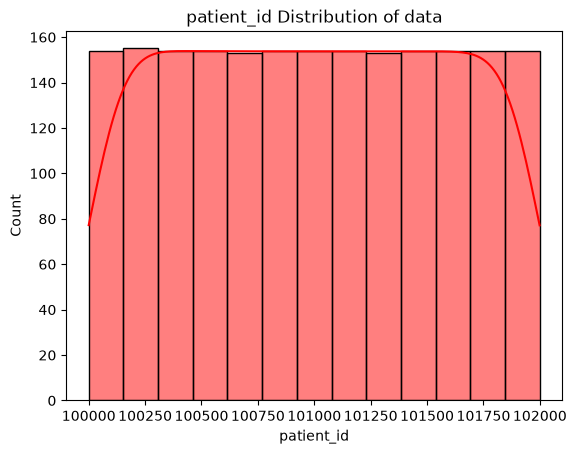


 age
********************
count    2001.000000
mean       53.731468
std        21.066002
min        18.000000
25%        35.000000
50%        54.000000
75%        72.000000
max       108.017232
Name: age, dtype: float64


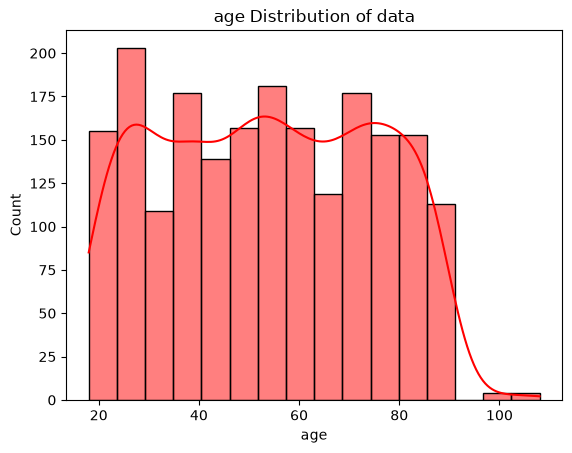


 bmi
********************
count    2001.000000
mean       26.309006
std         4.655843
min        14.000000
25%        23.200000
50%        26.309006
75%        29.200000
max        44.200000
Name: bmi, dtype: float64


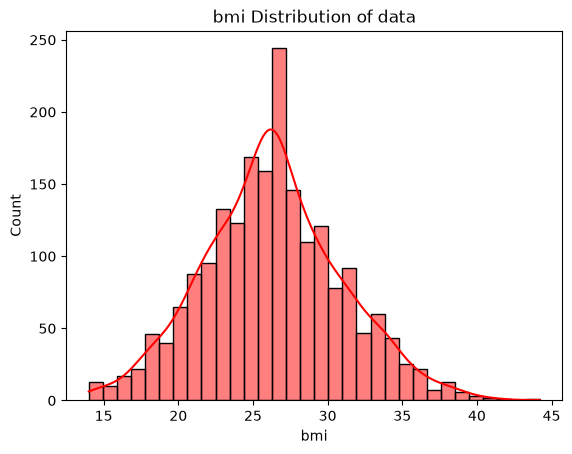


 systolic_bp
********************
count    2001.000000
mean      144.124366
std        14.129779
min       103.000000
25%       135.000000
50%       144.000000
75%       152.000000
max       258.041051
Name: systolic_bp, dtype: float64


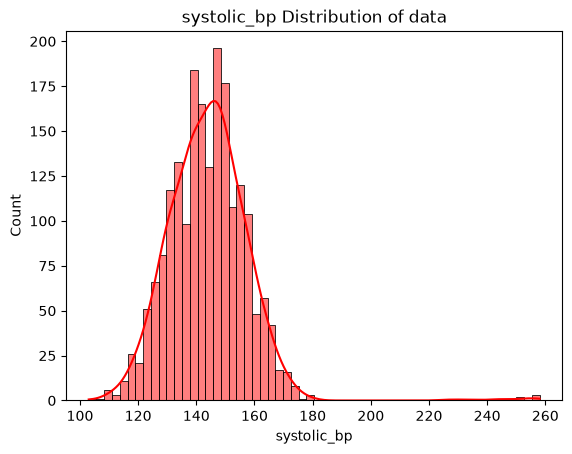


 diastolic_bp
********************
count    2001.000000
mean       86.178259
std         7.152074
min        62.000000
25%        81.000000
50%        86.000000
75%        91.000000
max       110.000000
Name: diastolic_bp, dtype: float64


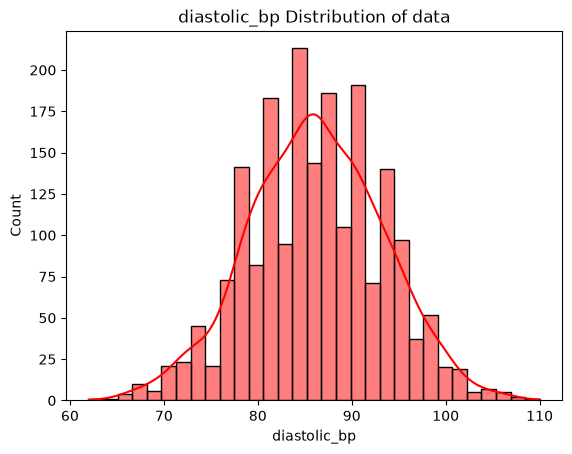


 cholesterol
********************
count    2001.000000
mean      216.317008
std        31.805239
min       148.000000
25%       199.000000
50%       216.317008
75%       231.000000
max       487.924410
Name: cholesterol, dtype: float64


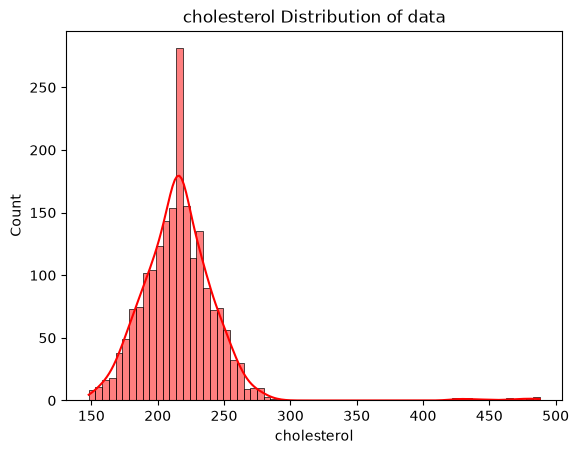


 glucose
********************
count    2001.000000
mean      118.578643
std        14.049119
min        62.000000
25%       109.000000
50%       118.578643
75%       128.000000
max       168.000000
Name: glucose, dtype: float64


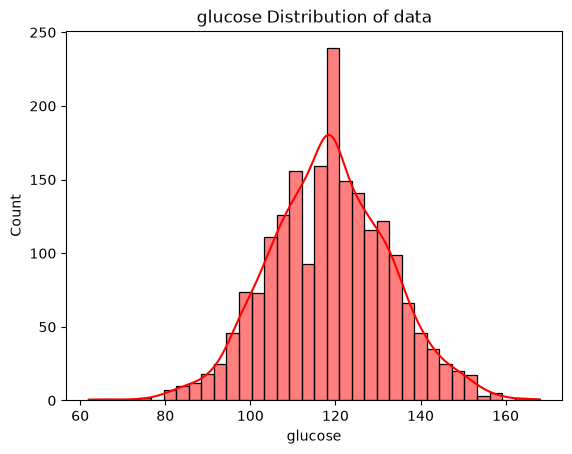


 heart_rate
********************
count    2001.000000
mean       71.175412
std         9.005316
min        41.000000
25%        65.000000
50%        71.000000
75%        77.000000
max        99.000000
Name: heart_rate, dtype: float64


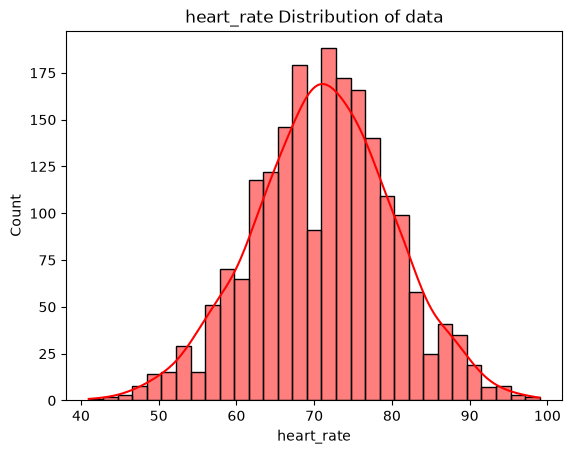


 annual_income
********************
count      2001.000000
mean      41575.012494
std       21947.658994
min      -57600.000000
25%       27400.000000
50%       37300.000000
75%       49300.000000
max      191700.000000
Name: annual_income, dtype: float64


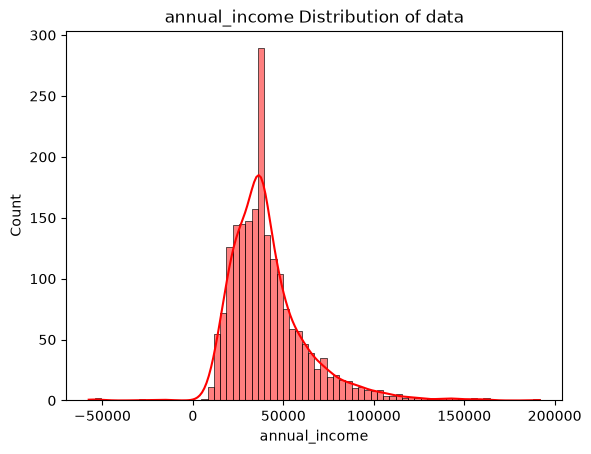


 hospital_visits_last_year
********************
count    2001.000000
mean        3.315342
std         1.879364
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        11.000000
Name: hospital_visits_last_year, dtype: float64


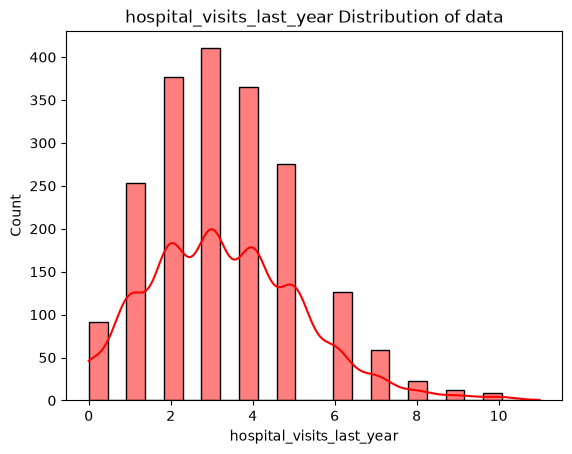

In [92]:
for col in numeric_features:
    
    print("\n",col)
    print("********************")
    print(df[col].describe())


    sns.histplot(df[col],kde=True,color="red")
    plt.title(f"{col} Distribution of data")
    plt.show()

In [ ]:
import math

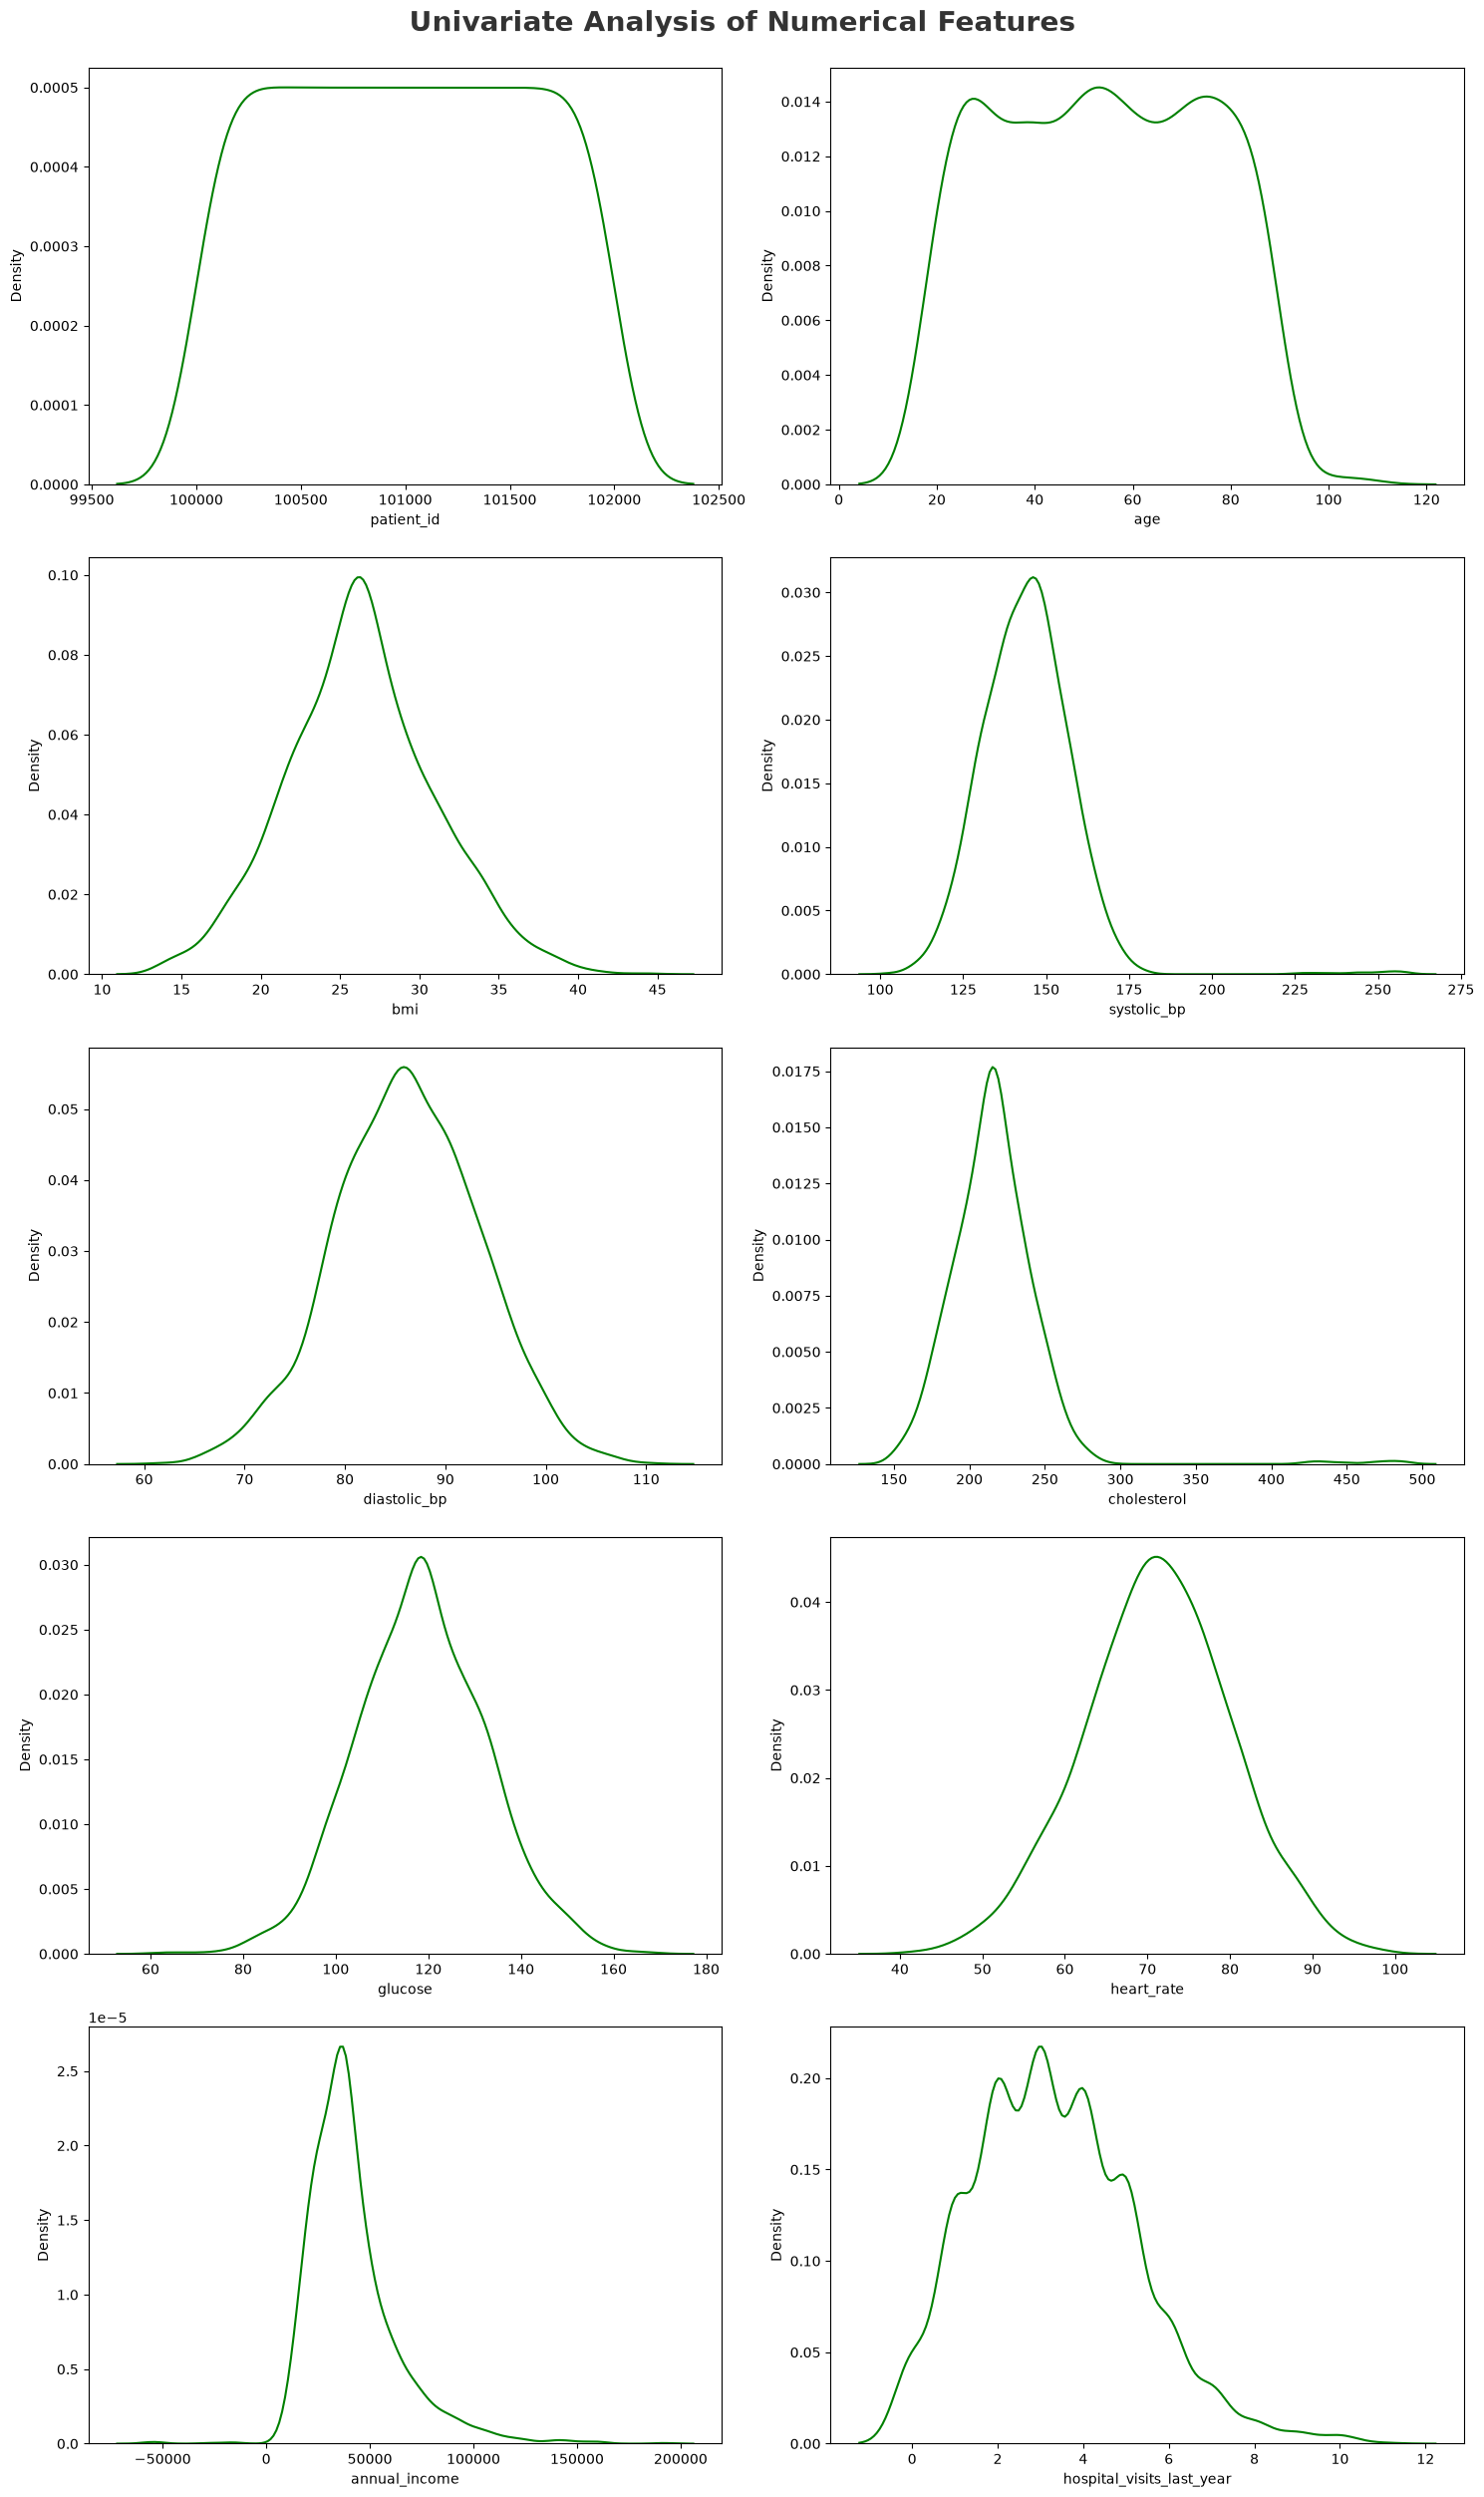

In [95]:
# Calculate the number of rows and columns based on the number of features
n_features = len(numeric_features)
n_cols = 2  # You can adjust this as needed (e.g., 2 columns for 6 features)
n_rows = int(np.ceil(n_features / n_cols))  # Calculate rows to fit all features

# Create the plot
plt.figure(figsize=(15, 5 * n_rows))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

# Loop to create subplots for each numerical feature
for i in range(n_features):
    plt.subplot(n_rows, n_cols, i+1)  # Dynamically set subplot grid
    sns.kdeplot(x=df[numeric_features[i]], color='green')
    plt.xlabel(numeric_features[i])

plt.tight_layout()
plt.show()

- analysis of categorical data


 gender
********************
count       2001
unique         2
top       Female
freq        1017
Name: gender, dtype: object


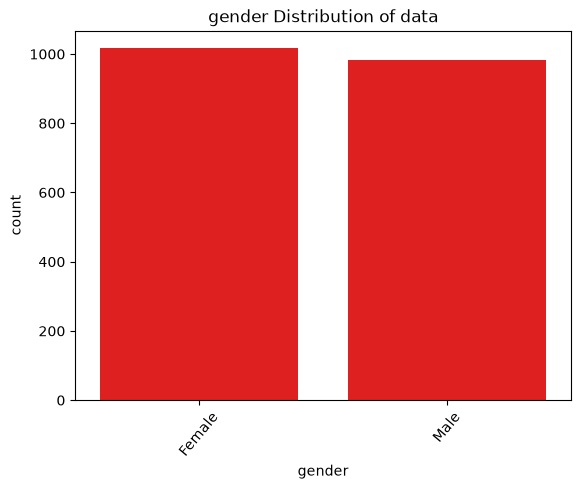


 region
********************
count      2001
unique        4
top       North
freq        587
Name: region, dtype: object


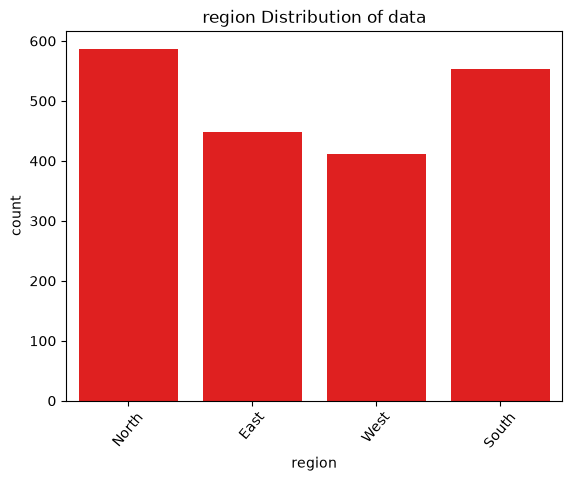


 smoking_status
********************
count      2001
unique        3
top       Never
freq       1105
Name: smoking_status, dtype: object


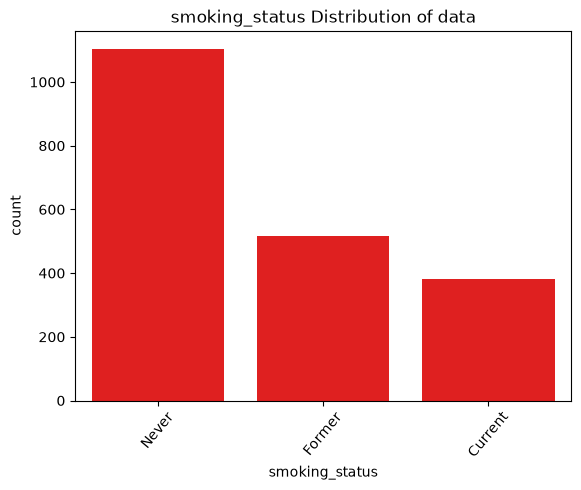


 exercise_level
********************
count         2001
unique           3
top       Moderate
freq           956
Name: exercise_level, dtype: object


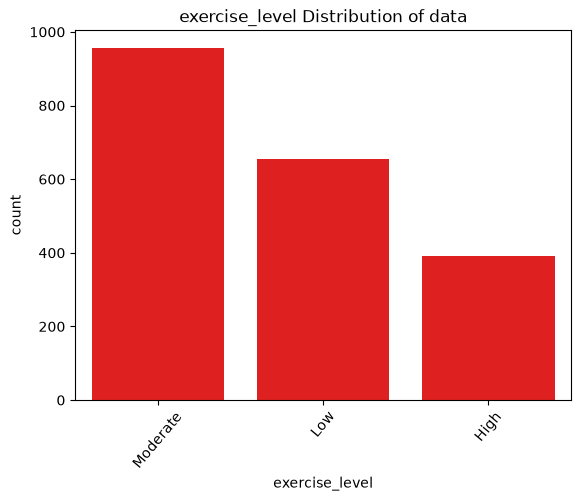


 family_history
********************
count     2001
unique       2
top         No
freq      1353
Name: family_history, dtype: object


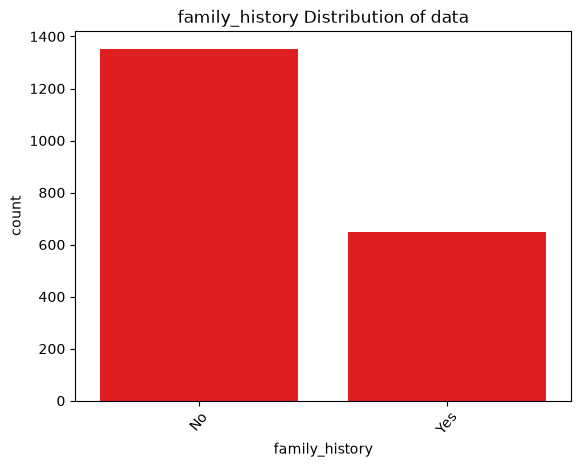


 heart_disease
********************
count     2001
unique       2
top        Yes
freq      1477
Name: heart_disease, dtype: object


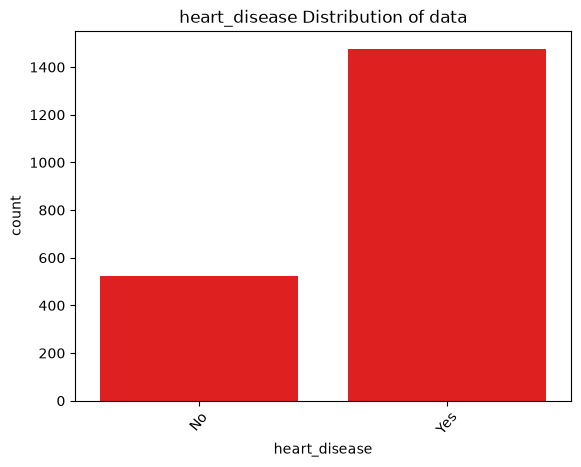

In [96]:
for col in categorical_features:
    
    print("\n",col)
    print("********************")
    print(df[col].describe())


    sns.countplot(x=df[col],color="red")
    plt.title(f"{col} Distribution of data")
    plt.xticks(rotation=50)
    plt.show()

- Bi variate analysis

- univariate analysis

- numerical data distribution

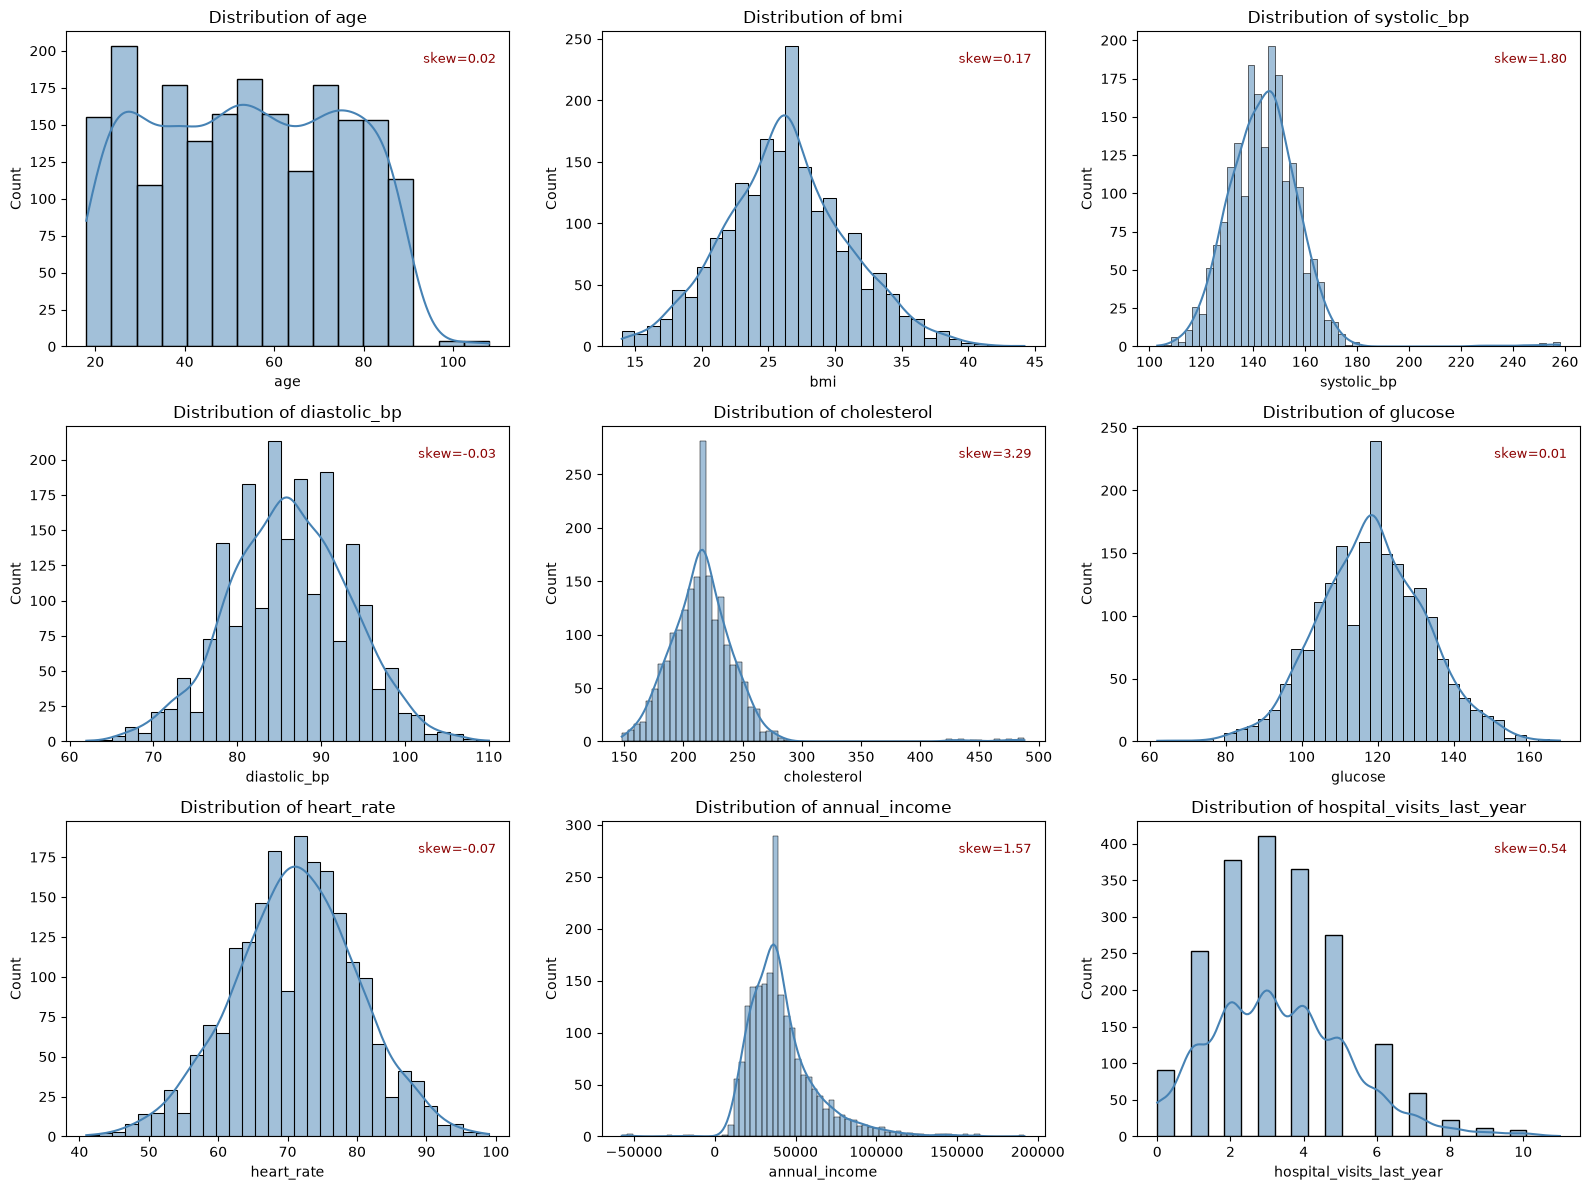

In [35]:
numeric_cols = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol',
                'glucose', 'heart_rate', 'annual_income', 'hospital_visits_last_year']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    skew = df[col].skew()
    axes[i].text(0.97, 0.9, f'skew={skew:.2f}', transform=axes[i].transAxes,
                 ha='right', fontsize=9, color='darkred')
plt.tight_layout()
plt.show()


In [37]:
# Age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 75, 120],
                          labels=['18-30', '31-45', '46-60', '61-75', '76+'])

# BMI category (WHO standard bands)
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Blood pressure category (simplified clinical bands)
def bp_category(row):
    if row['systolic_bp'] < 120 and row['diastolic_bp'] < 80:
        return 'Normal'
    elif row['systolic_bp'] < 130:
        return 'Elevated'
    elif row['systolic_bp'] < 140:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

df['bp_category'] = df.apply(bp_category, axis=1)

# Binary flag for convenience in numeric correlations
df['heart_disease_flag'] = (df['heart_disease'] == 'Yes').astype(int)

df[['age_group', 'bmi_category', 'bp_category', 'heart_disease_flag']].head()


,age_group,bmi_category,bp_category,heart_disease_flag
0,46-60,Underweight,Hypertension Stage 1,0
1,76+,Overweight,Hypertension Stage 2,1
2,31-45,Overweight,Hypertension Stage 1,1
3,61-75,Underweight,Hypertension Stage 2,1
4,18-30,Overweight,Hypertension Stage 2,1


- categorical data distribution

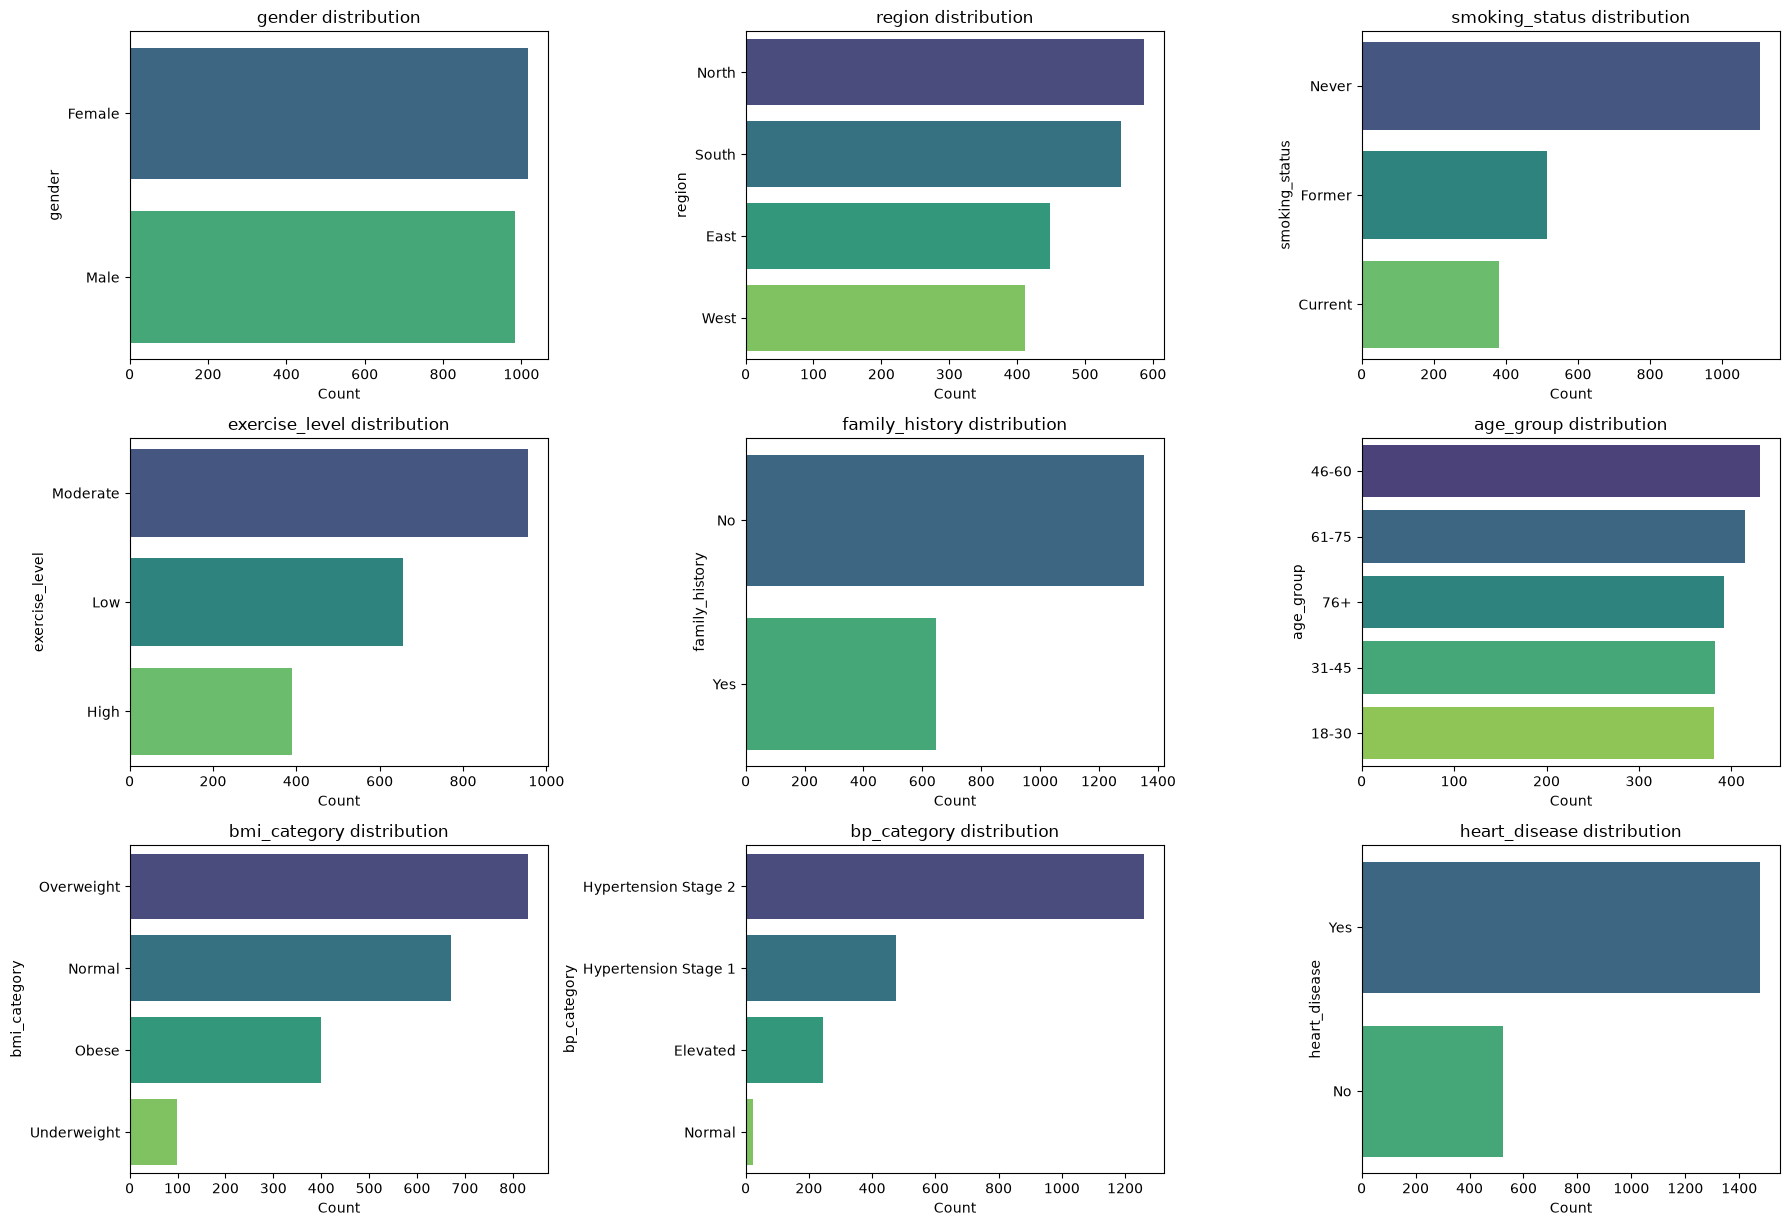

In [38]:
cat_cols = ['gender', 'region', 'smoking_status',
            'exercise_level', 'family_history', 'age_group', 'bmi_category',
            'bp_category', 'heart_disease']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel('Count')
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()